In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Website Performance Analysis.csv")

In [3]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [9]:
# Grabs the data from the very first row (index 0) of the dataset and sets it as the new column headers.
# This is usually done when a CSV file has an extra row at the top (like a comment or blank space) 
# and the real headers are pushed down to the first row of data.
df.columns = df.iloc[0]

# Deletes that first row (index=0) from the actual data since we just promoted it to be the header.
# .reset_index(drop=True) then resets the row numbers so they start cleanly from 0 again, 
# rather than starting at 1.
df = df.drop(index = 0).reset_index(drop = True)

# Manually renames all the columns in the dataframe to this specific list of clean, easy-to-type names.
# This overrides whatever the headers were previously, ensuring consistency for the rest of your analysis.
df.columns = [
    "Channel Group", "Date Hour", "Users", "Sessions", 
    "Engaged Session", "Average Engagement Time per Session", 
    "Engaged Sessions Per User", "Events Per Session", 
    "Engagement Rate", "Event Count"
]

In [10]:
df.head()

,Channel Group,Date Hour,Users,Sessions,Engaged Session,Average Engagement Time per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count
0,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
1,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
2,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
3,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001
4,Organic Social,2024041721,160,206,103,59.31553398058250,0.64375,4.694174757281550,0.5,967


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel Group                        3181 non-null   object
 1   Date Hour                            3181 non-null   object
 2   Users                                3181 non-null   object
 3   Sessions                             3181 non-null   object
 4   Engaged Session                      3181 non-null   object
 5   Average Engagement Time per Session  3181 non-null   object
 6   Engaged Sessions Per User            3181 non-null   object
 7   Events Per Session                   3181 non-null   object
 8   Engagement Rate                      3181 non-null   object
 9   Event Count                          3181 non-null   object
dtypes: object(10)
memory usage: 248.6+ KB


In [16]:
# Converts the "Date Hour" string or integer into a proper Pandas datetime format.
# `format="%Y%m%d%H"` tells Pandas exactly how to read the numbers (Year, Month, Day, Hour).
# `errors='coerce'` means if a value is corrupted and can't be read, it will be turned into an empty value (NaT) instead of crashing the program.
df["Date Hour"] = pd.to_datetime(df["Date Hour"], format="%Y%m%d%H", errors='coerce')

# Creates a list of all the column names in the dataset, but removes "Channel Group" and "Date Hour".
# This isolates only the columns that are supposed to contain numbers (like Sessions, Users, etc.).
numeric_cols = df.columns.drop(["Channel Group", "Date Hour"])

# Applies the `to_numeric` function to all those isolated columns simultaneously.
# This forces the data into integers or decimals. Again, `errors='coerce'` ensures that any weird text hiding in those columns gets turned into a blank (NaN) rather than causing an error.
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Reaches into the newly formatted "Date Hour" datetime column, extracts just the hour portion (0 to 23),
# and saves it as a brand new column named "Hour" at the end of the dataframe.
df["Hour"] = df["Date Hour"].dt.hour

In [19]:
df.head()

,Channel Group,Date Hour,Users,Sessions,Engaged Session,Average Engagement Time per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


In [21]:
df.describe()

,Date Hour,Users,Sessions,Engaged Session,Average Engagement Time per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count,Hour
count,3181,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000
mean,2024-04-20 01:18:31.348632576,41.874568,51.114429,28.289217,66.650591,0.606449,4.675970,0.503404,241.907891,11.803521
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:00:00,20.000000,24.000000,13.000000,32.097378,0.561404,3.750000,0.442857,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.040404,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.500000,0.750000,5.218182,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,208.000000,267.000000,132.000000,4525.000000,2.000000,56.000000,1.000000,1147.000000,23.000000
std,NaN,29.383942,36.661139,20.551668,127.220206,0.264064,2.795667,0.228241,183.318978,6.884907


# Q.1) What patterns or trends can you observe in website sessions and users over time?

### Sessions and user over time

In [24]:
sns.set(style="whitegrid")

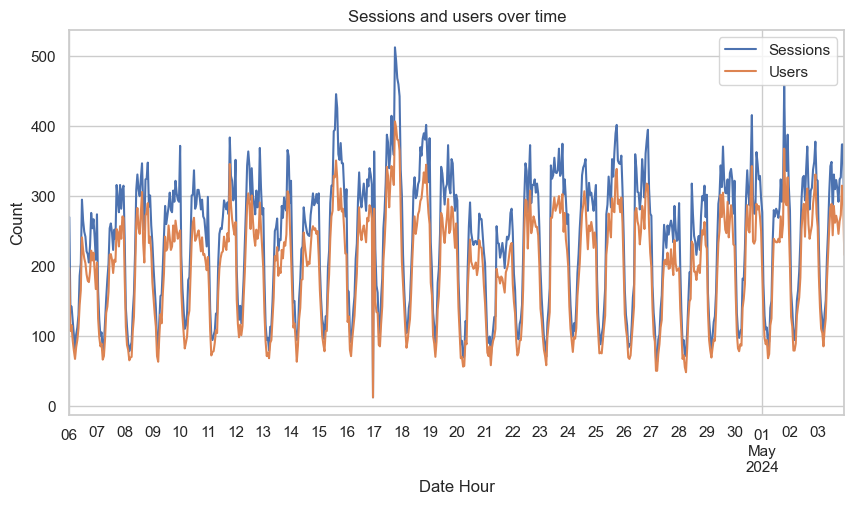

In [31]:
plt.figure(figsize=(10,5))
df.groupby("Date Hour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and users over time")
plt.xlabel("Date Hour")
plt.ylabel("Count")
plt.show()

# Q.2) Which marketing channel brought the highest number of users to the website, and how can we use this insight to improve traffic from other sources? 

### Total users by channel

C:\Users\vivek\AppData\Local\Temp\ipykernel_6548\1113362418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Channel Group", y="Users", estimator=np.sum, palette="viridis")


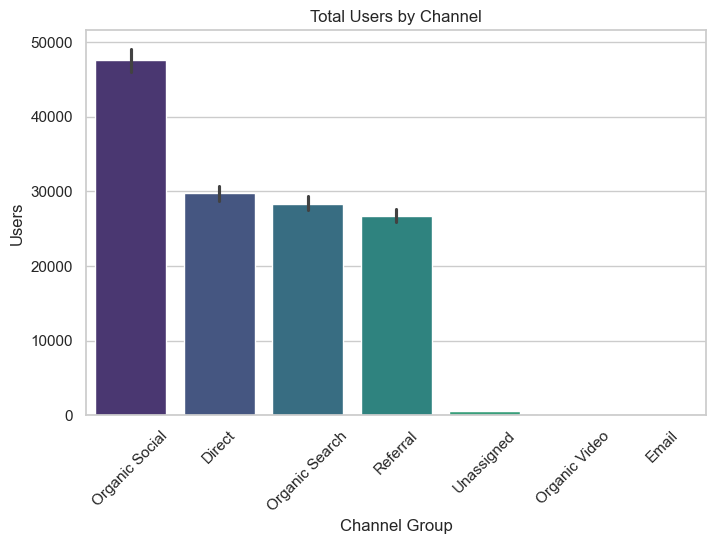

In [33]:
# Creates a new blank canvas (figure) for the plot. 
# figsize=(8,5) sets the width to 8 inches and the height to 5 inches.
plt.figure(figsize=(8,5))

# Uses Seaborn (sns) to draw a bar chart.
# data=df: Tells it to pull information from your 'df' dataframe.
# x="Channel Group", y="Users": Sets the x-axis to show channels and the y-axis to show user counts.
# estimator=np.sum: Instead of showing the average (which is the default), this adds up the total users for each channel.
# palette="viridis": Applies a visually appealing color theme to the bars.
sns.barplot(data=df, x="Channel Group", y="Users", estimator=np.sum, palette="viridis")

# Adds a title to the very top of the chart.
plt.title("Total Users by Channel")

# Rotates the text labels on the x-axis by 45 degrees. 
# This prevents long channel names (like "Organic Social") from overlapping into an unreadable mess.
plt.xticks(rotation=45)

# Commands Python to actually render and display the finished chart on your screen.
plt.show()

# 3) Which channel has the highest average engagement time, and what does that tell us about user behavior and content effectiveness?

### Average Engagement Time by Channel

C:\Users\vivek\AppData\Local\Temp\ipykernel_6548\2512141291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Channel Group", y="Average Engagement Time per Session", estimator=np.mean, palette="magma")


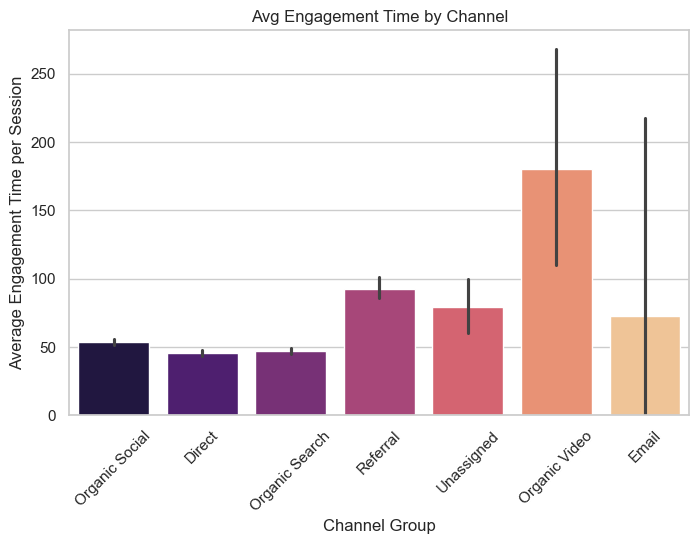

In [38]:
# Creates a new blank figure (the canvas for the plot).
# figsize=(8,5) sets the width to 8 inches and the height to 5 inches.
plt.figure(figsize=(8,5))

# Uses Seaborn (sns) to draw a bar chart.
# data=df: Tells the function to pull data from your dataframe named 'df'.
# x="Channel Group", y="...": Sets the channels on the x-axis and the engagement time on the y-axis.
# estimator=np.mean: Calculates the average (mean) engagement time for each channel (this is the default behavior, but it's good to be explicit).
# palette="magma": Applies the 'magma' color theme (a dark-to-light gradient) to the bars.
sns.barplot(data=df, x="Channel Group", y="Average Engagement Time per Session", estimator=np.mean, palette="magma")

# Adds a title to the top of the chart.
plt.title("Avg Engagement Time by Channel")

# Rotates the text labels on the x-axis by 45 degrees.
# This ensures long channel names don't overlap and remain readable.
plt.xticks(rotation=45)

# Renders and displays the final plot on your screen.
plt.show()

# Q. 4) How does engagement rate vary across different traffic channels?

### Enagagement Rate Distribution by Channel

C:\Users\vivek\AppData\Local\Temp\ipykernel_6548\3608369839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Channel Group", y="Engagement Rate", palette="coolwarm")


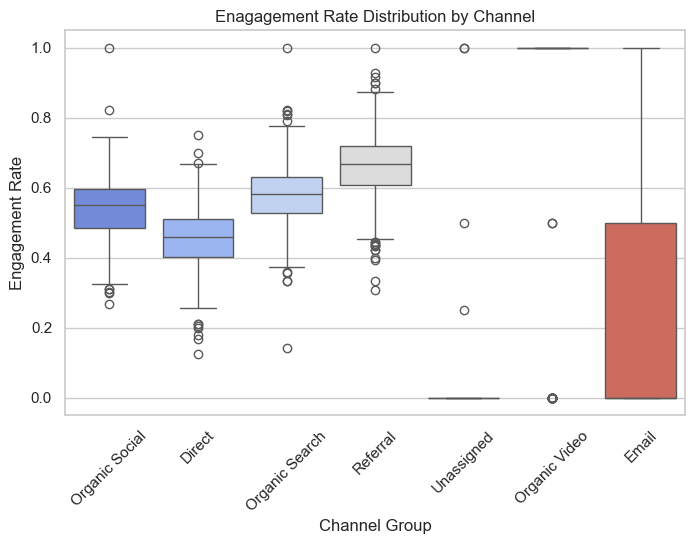

In [39]:
# Creates a new blank figure (the canvas) for the plot.
# figsize=(8,5) sets the width to 8 inches and the height to 5 inches.
plt.figure(figsize=(8,5))

# Uses Seaborn (sns) to draw a boxplot. Boxplots are great for showing the distribution of data 
# (including the median, the typical range, and any extreme outlier data points).
# data=df: Pulls the data from your dataframe named 'df'.
# x="Channel Group", y="Engagement Rate": Groups the data by channel on the x-axis and shows the spread of their engagement rates on the y-axis.
# palette="coolwarm": Applies a color theme that shifts from cool (blue) to warm (red) colors across the boxes.
sns.boxplot(data=df, x="Channel Group", y="Engagement Rate", palette="coolwarm")

# Adds a title to the very top of the chart.
plt.title("Engagement Rate Distribution by Channel")

# Rotates the text labels on the x-axis by 45 degrees.
# This prevents the names of the channels from overlapping so they are easy to read.
plt.xticks(rotation=45)

# Commands Python to actually render and display the finished chart on your screen.
plt.show()

# Q. 5) Which channels are driving more engaged sessions compared to non-engaged  ones, and what strategies can improve engagement in underperforming channels?

### Engaged vs Non Engaged Session

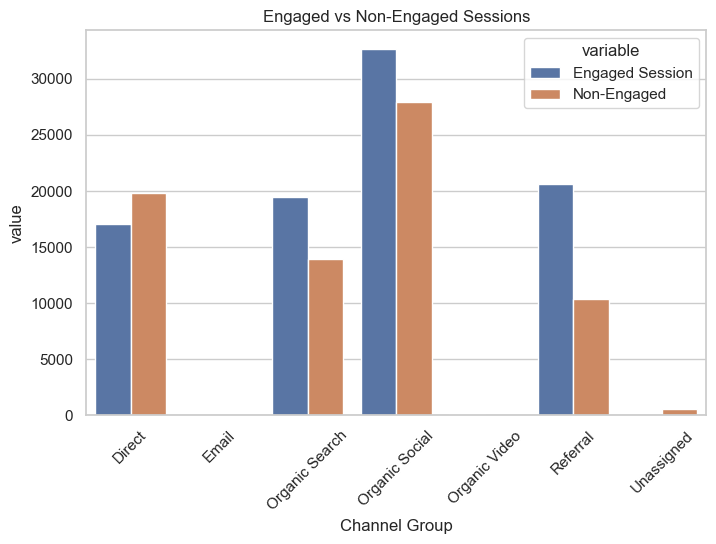

In [48]:
# Group the dataset by each marketing channel, then calculate the total sum of both "Sessions" and "Engaged Session"
# .reset_index() is used to turn "Channel Group" back into a regular column so Seaborn can use it for the x-axis later
session_df = df.groupby("Channel Group")[["Sessions", "Engaged Session"]].sum().reset_index()

# Create a brand new column called "Non-Engaged"
# We calculate this by taking the total sessions and subtracting the ones that were actually engaged
session_df["Non-Engaged"] = session_df["Sessions"] - session_df["Engaged Session"]

# .melt() reshapes the dataframe from a "wide" format to a "long" format.
# It keeps "Channel Group" as the anchor (id_vars), but takes the "Engaged Session" and "Non-Engaged" 
# columns and stacks them. This creates two new standard columns behind the scenes: 
# one called 'variable' (containing the text "Engaged Session" or "Non-Engaged") and one called 'value' (containing the numbers).
# Seaborn requires the data in this exact shape to plot grouped bars side-by-side!
session_df_melted = session_df.melt(id_vars="Channel Group", value_vars=["Engaged Session", "Non-Engaged"])

# Create a new blank canvas for the plot, 8 inches wide by 5 inches tall
plt.figure(figsize=(8, 5))

# Draw the bar chart.
# data=session_df_melted: Uses our newly reshaped dataset.
# x="Channel Group": Places the marketing channels along the bottom axis.
# y="value": Determines the height of the bars using the numeric counts.
# hue="variable": Tells Seaborn to split each channel into two differently colored bars based on our melted categories.
sns.barplot(data=session_df_melted, x="Channel Group", y="value", hue="variable")

# Add a descriptive title to the very top of the chart
plt.title("Engaged vs Non-Engaged Sessions")

# Rotate the channel names on the x-axis by 45 degrees so they don't overlap into an unreadable mess
plt.xticks(rotation=45)

# Render and display the final chart on your screen
plt.show()

# Q. 6) At what hours of the day does each channel drive the most traffic?

### Traffic by Hour and Channel

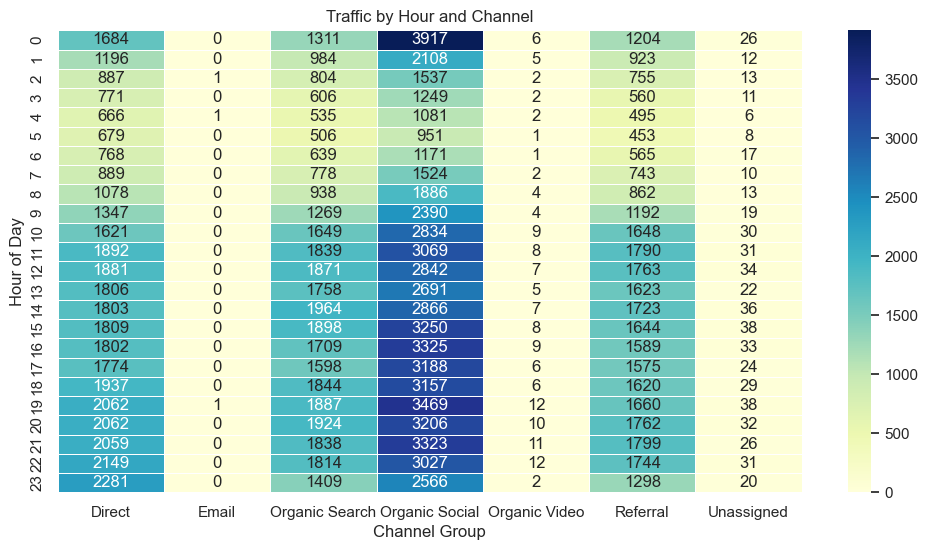

In [53]:
# Group the data by both 'Hour' and 'Channel Group', then calculate the total sum of "Sessions" for each combination.
# .unstack() reshapes the result: it takes the "Channel Group" index and turns it into columns, creating a 2D grid/table format which is required to build a heatmap.
# .fillna(0) ensures that if a specific channel had no traffic during a certain hour (which would normally show as 'NaN' or empty), it is safely replaced with a 0.
heatmap_data = df.groupby(["Hour", "Channel Group"])["Sessions"].sum().unstack().fillna(0)

# Create a new blank canvas for the plot, making it extra wide (12 inches) and 6 inches tall
# to accommodate the 24 hours and multiple channels without looking squished.
plt.figure(figsize=(12, 6))

# Draw the heatmap using Seaborn.
# data=heatmap_data: Feeds in our newly created 2D grid of numbers.
# cmap="YlGnBu": Applies a "Yellow to Green to Blue" color palette. Lower numbers are yellow, higher numbers are dark blue.
# linewidths=.5: Adds a small white gap between the squares so they don't bleed into each other.
# annot=True: Actually prints the exact number of sessions inside each colored box.
# fmt='.0f': Formats those printed numbers as clean, whole integers (0 decimal places) so they fit inside the boxes.
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, annot=True, fmt='.0f')

# Add a descriptive title to the top of the chart.
plt.title("Traffic by Hour and Channel")

# Explicitly label the X-axis (bottom) and Y-axis (left side) so viewers know what the grid represents.
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

# Render and display the final chart on your screen.
plt.show()

# Q. 7) Is there any correlation between high traffic (sessions) and high engagement rate over time? 

### Enagement Rate vs Session Over Time

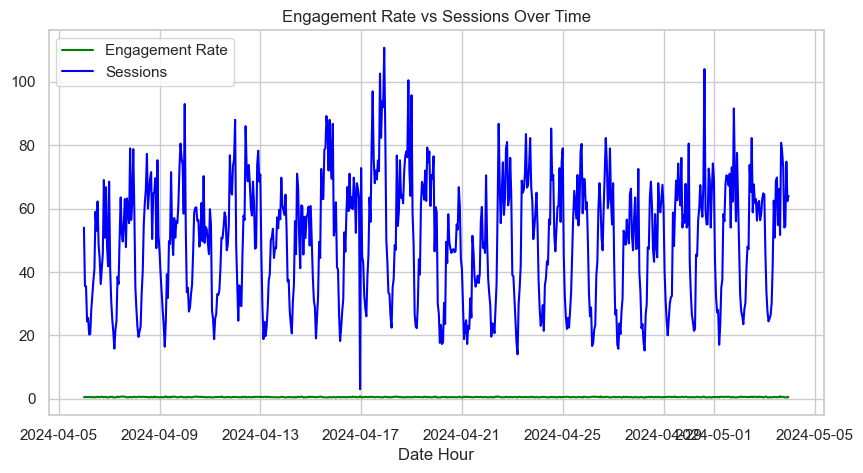

In [57]:
# Group the data by "Date Hour", then calculate the average (mean) for both "Engagement Rate" and "Sessions".
# .reset_index() turns "Date Hour" back into a normal column so we can plot it on the x-axis.
df_plot = df.groupby("Date Hour")[["Engagement Rate", "Sessions"]].mean().reset_index()

# Create a new blank canvas for the plot, 10 inches wide and 5 inches tall.
plt.figure(figsize=(10, 5))

# Draw the first line for Engagement Rate.
# x="Date Hour", y="Engagement Rate", and we color the line green.
plt.plot(df_plot["Date Hour"], df_plot["Engagement Rate"], label="Engagement Rate", color="green")

# Draw the second line for Sessions right on top of the same graph.
# x="Date Hour", y="Sessions", and we color the line blue.
plt.plot(df_plot["Date Hour"], df_plot["Sessions"], label="Sessions", color="blue")

# Add a descriptive title to the top of the chart.
plt.title("Engagement Rate vs Sessions Over Time")

# Label the x-axis so viewers know the bottom represents time.
plt.xlabel("Date Hour")

# Display a legend (the little box that tells you Green = Engagement Rate, Blue = Sessions)
# using the 'label=' text we provided in the plt.plot() lines above.
plt.legend()

# Turn on the background grid lines to make it easier to read the exact values.
plt.grid(True)

# Render and display the final chart on your screen.
plt.show()